# 🚚 Freight Rate Prediction

**Goal:** forecast the posted rate (`posted_rate`, in \$) of **12,000 loads for Nov–Dec 2025**, using 48,000 labeled loads from Jan–Oct 2025. Also produce a fixed December price curve for one lane.

<table>
<tr><td><b>Final model</b></td><td>LightGBM for load shape <b>+</b> linear terms for market level, time trend and city effects (kNN fallback for unseen cities)</td></tr>
<tr><td><b>Validation</b></td><td>Rolling-origin (forward-in-time) CV, 5 folds, 2-month horizon, everything refit inside each fold</td></tr>
<tr><td><b>Forward-CV result</b></td><td><b>MAE ≈ \$105 · MAPE ≈ 4.5%</b> (plain LightGBM: \$120 · 5.0%, per-mile baseline: \$221 · 10.5%)</td></tr>
<tr><td><b>Key data issue</b></td><td>~1.4% of training labels are corrupted (spikes and drops unrelated to any feature) → removed from <i>training only</i></td></tr>
</table>

### Contents
1. [Task and data](#1.-Task-and-data)
2. [Data-quality audit](#2.-Data-quality-audit)
3. [Exploring the data](#3.-Exploring-the-data)
4. [Validation strategy](#4.-Validation-strategy)
5. [The model](#5.-The-model)
6. [Results](#6.-Results)
7. [Decision log](#7.-Decision-log)
8. [Final predictions and December chart](#8.-Final-predictions-and-December-chart)
9. [Limitations and next steps](#9.-Limitations-and-next-steps)

> The reusable code lives in `src/freight_rate/`. This notebook imports it and shows the important parts inline, so there is a single source of truth.

In [1]:
import inspect
import subprocess
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore")

# Works whether the notebook is opened from the repo root or from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from freight_rate import validation as V
from freight_rate.config import CLEAN_THRESHOLD, FIG_DIR, FOLDS, OUT_DIR, TARGET
from freight_rate.data import daily_context, load_all
from freight_rate.model import FreightModel
from freight_rate.submission import december_submission, validation_submission

TEAL, ORANGE, GREY, RED = "#064A56", "#D9822B", "#9DAFB3", "#B23A48"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E3EAEC", "axes.titleweight": "bold",
    "axes.titlesize": 11, "axes.labelsize": 9.5, "font.size": 9.5,
})
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def show_source(obj):
    # Render the source of a function/class from src/ as a code block.
    display(Markdown("```python\n" + inspect.getsource(obj) + "\n```"))

train, val, template, december = load_all()
ctx = daily_context(train, val)   # per-day market level from FEATURE columns only

---
## 1. Task and data

Three files matter. The most important structural fact is **time**: the labeled data ends on Oct 31 and the loads to predict start on Nov 1. This is a *forecast*, not an interpolation, and that decision drives the validation design (§4) and the model choice (§5).

In [2]:
overview = pd.DataFrame({
    "rows": [len(train), len(val), len(december)],
    "first date": [train.date.min().date(), val.date.min().date(), december.date.min().date()],
    "last date": [train.date.max().date(), val.date.max().date(), december.date.max().date()],
    "has label": ["yes (posted_rate)", "no (12,000 to predict)", "no (31 to predict)"],
}, index=["train_test.csv", "validation.csv", "december_chart_inputs.csv"])
display(overview)
print("Train and validation load_ids overlap:", len(set(train.load_id) & set(val.load_id)), "(none)")

,rows,first date,last date,has label
train_test.csv,48000,2025-01-01,2025-10-31,yes (posted_rate)
validation.csv,12000,2025-11-01,2025-12-31,"no (12,000 to predict)"
december_chart_inputs.csv,31,2025-12-01,2025-12-31,no (31 to predict)


Train and validation load_ids overlap: 0 (none)


**Features:** `pickup`, `delivery` (64 cities), their coordinates, `distance`, `equipment` (Dry Van / Reefer / Flatbed), `weight`, `date`, plus two market signals, `market_index` and `quote_signal`.
**December chart:** one fixed lane (Lexington → Fort Wayne, 360 mi, Dry Van, 32,000 lb) where only the date changes, so it isolates how the model treats time and the market.

---
## 2. Data-quality audit

I checked every column for missing values, impossible values, duplicates, and train/validation mismatches. Each finding below has a decision attached.

In [3]:
unseen = (set(val.pickup) | set(val.delivery)) - (set(train.pickup) | set(train.delivery))
touch_unseen = val.pickup.isin(unseen) | val.delivery.isin(unseen)

audit = pd.DataFrame([
    ("Missing `weight`",               train.weight.isna().sum(),   val.weight.isna().sum(),   "Kept as NaN; LightGBM handles missing values natively"),
    ("Missing `market_index`",         train.market_index.isna().sum(), val.market_index.isna().sum(), "Replaced by that day's level (see §3); a daily signal is recoverable from other rows"),
    ("Negative `weight`",              (train.weight < 0).sum(),    (val.weight < 0).sum(),    "Sign flips (magnitudes look normal) → use absolute value"),
    ("`distance` stuck at 70 mi floor", (train.distance == 70).sum(), (val.distance == 70).sum(), "Price with `distance`; loads at the floor end up over-predicted by ~7% (§6.4)"),
    ("Duplicate `load_id`",            train.load_id.duplicated().sum(), val.load_id.duplicated().sum(), "None"),
    ("Cities only in validation",      0, len(unseen),                                         f"{touch_unseen.mean():.1%} of validation rows touch one → kNN fallback on coordinates (§5)"),
], columns=["Issue", "train", "validation", "Decision"])
display(audit.style.hide(axis="index").set_properties(subset=["Decision"], **{"text-align": "left"}))
print("Cities appearing only in validation:", sorted(unseen))

Issue,train,validation,Decision
Missing `weight`,300,165,Kept as NaN; LightGBM handles missing values natively
Missing `market_index`,374,249,Replaced by that day's level (see §3); a daily signal is recoverable from other rows
Negative `weight`,292,145,Sign flips (magnitudes look normal) → use absolute value
`distance` stuck at 70 mi floor,48,21,Price with `distance`; loads at the floor end up over-predicted by ~7% (§6.4)
Duplicate `load_id`,0,0,None
Cities only in validation,0,8,12.1% of validation rows touch one → kNN fallback on coordinates (§5)


Cities appearing only in validation: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']


**Coordinates add nothing beyond `distance`, and are not real geography.** Each city has one fixed coordinate pair (good). The distance those coordinates imply lines up almost perfectly with the `distance` column (`distance` ≈ 1.18 × coordinate distance, with a 70-mile minimum), so the coordinates carry no *extra* pricing information. They are also not real-world accurate. I therefore price with `distance` and use coordinates only to place cities on a coarse map, which is exactly what the unseen-city fallback needs.

corr(coordinate distance, distance column) = 1.000
distance / coordinate-distance: median 1.18, 5th-95th pct 1.14 to 1.27
e.g. New Orleans → Shreveport: coordinates imply 7 mi, the distance column says 70 mi (the 70-mile floor); the real road distance is several hundred


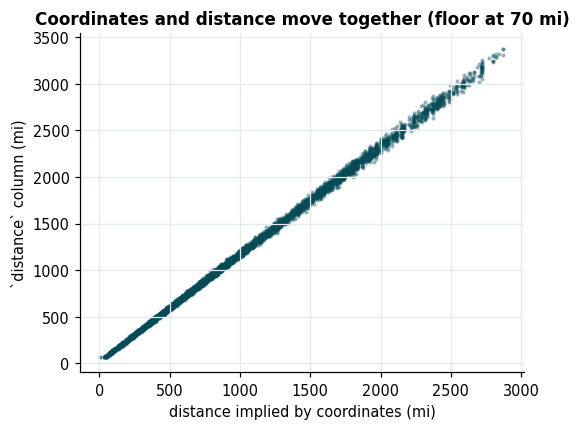

In [4]:
def haversine_miles(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 3958.8 * 2 * np.arcsin(np.sqrt(a))

geo = haversine_miles(train.pickup_lat, train.pickup_lon, train.delivery_lat, train.delivery_lon)
ratio = (train.distance / geo).replace([np.inf, -np.inf], np.nan).dropna()
print(f"corr(coordinate distance, distance column) = {np.corrcoef(geo, train.distance)[0, 1]:.3f}")
print(f"distance / coordinate-distance: median {ratio.median():.2f}, 5th-95th pct {ratio.quantile(.05):.2f} to {ratio.quantile(.95):.2f}")

ex = train[(train.pickup == "New Orleans") & (train.delivery == "Shreveport")].iloc[0]
print(f"e.g. New Orleans → Shreveport: coordinates imply {haversine_miles(ex.pickup_lat, ex.pickup_lon, ex.delivery_lat, ex.delivery_lon):.0f} mi, "
      f"the distance column says {ex.distance:.0f} mi (the 70-mile floor); the real road distance is several hundred")

fig, ax = plt.subplots(figsize=(5.2, 4))
s = train.sample(6000, random_state=0)
ax.scatter(geo.loc[s.index], s.distance, s=3, alpha=.3, color=TEAL)
ax.set(xlabel="distance implied by coordinates (mi)", ylabel="`distance` column (mi)", title="Coordinates and distance move together (floor at 70 mi)")
plt.show()

**Suspicious labels.** `posted_rate` per mile has a median of about \$2.15 but ranges from \$0.33 to \$14.1. Those extremes are too far out to be real pricing variation. I quantify them in §5 once a model exists to say what each rate *should* have been.

---
## 3. Exploring the data

What actually drives the rate? Four views.

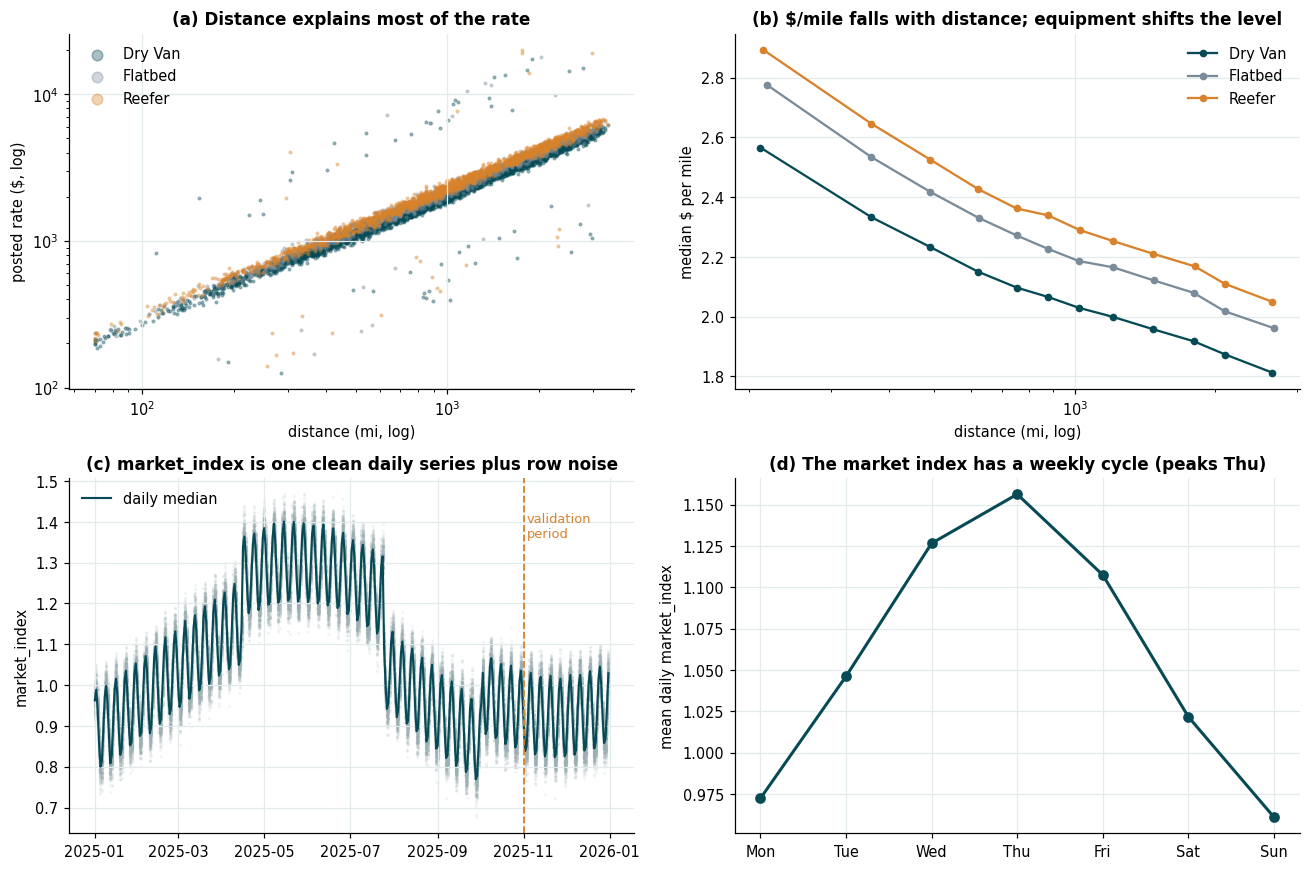

Share of variance that is BETWEEN days:  market_index 97.8%   quote_signal 19.7%


In [5]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
colors = {"Dry Van": TEAL, "Reefer": ORANGE, "Flatbed": "#7A8B99"}

# (a) rate vs distance
a = ax[0, 0]
s = train.sample(7000, random_state=1)
for eq, g in s.groupby("equipment"):
    a.scatter(g.distance, g.posted_rate, s=3, alpha=.35, color=colors[eq], label=eq)
a.set(xscale="log", yscale="log", xlabel="distance (mi, log)", ylabel="posted rate ($, log)", title="(a) Distance explains most of the rate")
a.legend(markerscale=4, frameon=False)

# (b) rate per mile vs distance
b = ax[0, 1]
tmp = train.assign(rpm=train.posted_rate / train.distance,
                   bucket=pd.qcut(train.distance, 12, duplicates="drop"))
for eq, g in tmp.groupby("equipment"):
    m = g.groupby("bucket", observed=True).agg(d=("distance", "median"), rpm=("rpm", "median"))
    b.plot(m.d, m.rpm, marker="o", ms=4, color=colors[eq], label=eq)
b.set(xscale="log", xlabel="distance (mi, log)", ylabel="median $ per mile", title="(b) $/mile falls with distance; equipment shifts the level")
b.legend(frameon=False)

# (c) market_index over time, train + validation
c = ax[1, 0]
both = pd.concat([train[["date", "market_index"]], val[["date", "market_index"]]])
c.scatter(both.date, both.market_index, s=1.5, alpha=.08, color=GREY)
c.plot(ctx.index, ctx.mi, color=TEAL, lw=1.4, label="daily median")
c.axvline(pd.Timestamp("2025-11-01"), color=ORANGE, ls="--", lw=1.2)
c.text(pd.Timestamp("2025-11-03"), both.market_index.max() * .97, "validation\nperiod", color=ORANGE, fontsize=8.5, va="top")
c.set(ylabel="market_index", title="(c) market_index is one clean daily series plus row noise")
c.legend(frameon=False, loc="upper left")

# (d) weekly cycle
d = ax[1, 1]
weekly = ctx.mi.groupby(ctx.index.dayofweek).mean()
d.plot(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], weekly.values, marker="o", color=TEAL, lw=2)
d.set(ylabel="mean daily market_index", title="(d) The market index has a weekly cycle (peaks Thu)")
plt.tight_layout()
plt.show()

def between_day_share(col):
    day_mean = train.groupby("date")[col].transform("mean")
    return 1 - (train[col] - day_mean).var() / train[col].var()
print(f"Share of variance that is BETWEEN days:  market_index {between_day_share('market_index'):.1%}   quote_signal {between_day_share('quote_signal'):.1%}")

**What I take from this**

- **Distance and equipment dominate.** Rate is roughly proportional to distance, with \$/mile falling on long hauls, so I model **log(rate)** against **log(distance)**. Reefer > Flatbed > Dry Van.
- **`market_index` is really a daily series.** About 98% of its variance is between days; the row-level value is that day's level plus noise (and some blanks). The daily median is therefore a cleaner and gap-free version, and it keeps going into Nov–Dec, so the model can see the market level of the days it must predict.
- **The market moves in regimes.** Panel (c) shows a ramp up to spring, a step down in late July, then a calmer mid-level stretch. The Nov–Dec validation period sits in that mid-level range (roughly 0.85–1.05), well inside what the model has already seen, so the *market level* needs no extrapolation; only the time trend does.
- **`quote_signal` is mostly per-load noise** (only ~20% of its variance is between days), so only its *daily mean* is worth using.
- **Raw correlations mislead.** `corr(rate, market_index)` is only 0.03 because distance swamps everything. The market effect only shows up **after removing load shape** (§5).

In [6]:
print("Raw correlations with posted_rate:")
print(train[["distance", "weight", "market_index", "quote_signal", TARGET]].corr()[TARGET].drop(TARGET).round(3).to_string())

Raw correlations with posted_rate:
distance        0.909
weight          0.035
market_index    0.034
quote_signal   -0.040


---
## 4. Validation strategy

**The validation set is a forecast, so validation must be a forecast.**

A random train/test split would let the model train on days on *both sides* of every test row, which the real task never allows. Instead I use **rolling-origin (expanding-window) validation**:

- fit on everything **before** a cutoff date,
- score the **following two months**,
- repeat for five cutoffs (May → Sep).

The **two-month horizon** mirrors the real gap (train ends Oct 31 → predict Nov–Dec). Every step (cleaning threshold, city effects, market context, model weights) is **refit from scratch inside each fold**, so no fold sees its own future.

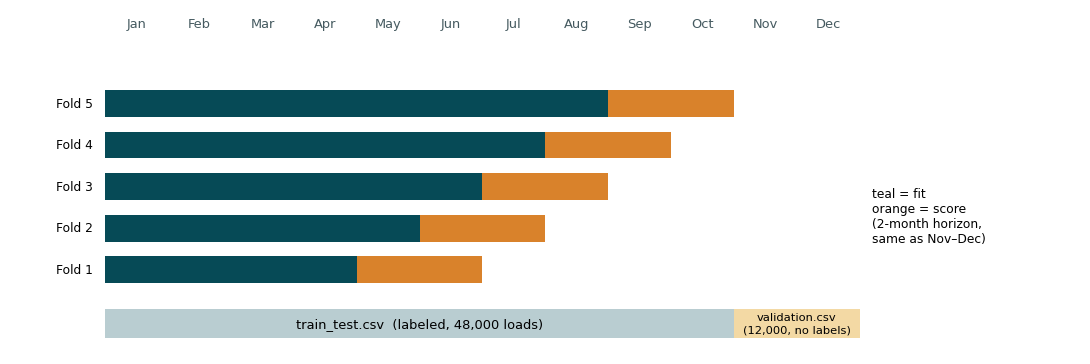

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.4))
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
for i, m in enumerate(months):
    ax.text(i + .5, 6.05, m, ha="center", fontsize=8.5, color="#455A60")
ax.barh(0, 10, color="#B9CDD1", height=.6)
ax.text(5, 0, "train_test.csv  (labeled, 48,000 loads)", ha="center", va="center", fontsize=8.5)
ax.barh(0, 2, left=10, color="#F3D9A4", height=.6)
ax.text(11, 0, "validation.csv\n(12,000, no labels)", ha="center", va="center", fontsize=7.5)
for j, (start, end) in enumerate(FOLDS):
    a, b = pd.Timestamp(start).month - 1, pd.Timestamp(end).month - 1 if pd.Timestamp(end).month > 1 else 12
    y = 1.1 + j * .85
    ax.barh(y, a, color=TEAL, height=.55)
    ax.barh(y, b - a, left=a, color=ORANGE, height=.55)
    ax.text(-.2, y, f"Fold {j + 1}", ha="right", va="center", fontsize=8)
ax.text(12.2, 2.2, "teal = fit\norange = score\n(2-month horizon,\nsame as Nov–Dec)", fontsize=8, va="center")
ax.set(xlim=(-1.5, 15.5), ylim=(-.6, 6.4)); ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "split_schematic.png", dpi=200)
plt.show()

**Honest caveat.** I compared model designs on these same five folds, so the reported numbers are slightly optimistic. The only true holdout is the Nov–Dec labels held by the reviewer.

---
## 5. The model

### 5.1 Three models, from simple to final

| # | Model | Purpose |
|---|---|---|
| 1 | Median \$/mile by equipment × distance | "No ML" floor: what a rule of thumb achieves |
| 2 | Plain LightGBM on all raw features (l1 objective, log target) | The obvious strong default |
| 3 | **Hybrid: LightGBM + linear terms** | Final model |

### 5.2 Why a hybrid?

A gradient-boosted tree predicts by looking up regions of the training data. **It cannot extrapolate**: for a date later than any it has seen, it just repeats its last known behaviour. Our validation window is *entirely* after the training data, and the rate drifts upward over time, so a tree-only model will lag.

A linear term *can* continue a trend. So I split the job:

$$\log(\text{rate}) \;=\; \underbrace{\text{GBM}(\log\text{distance},\ |\text{weight}|,\ \text{equipment})}_{\text{non-linear load shape}} \;+\; \underbrace{\beta_1 \log(\text{market}_{day}) + \beta_2\,\text{row deviation} + \beta_3\,\text{quote}_{day} + \beta_4\,\text{months} + \text{city}_{pickup} + \text{city}_{delivery}}_{\text{terms that must extrapolate}}$$

The two parts are fit by **backfitting** (alternately fitting each to the other's leftovers), and **corrupted labels are dropped between passes** so the final GBM only trains on clean rows. Cities never seen in training get the average effect of their **4 nearest known cities by coordinates**.

Here is the core of the implementation (imported from `src/freight_rate/model.py`):

In [8]:
show_source(FreightModel.fit)

```python
    def fit(self, d: pd.DataFrame, y: np.ndarray) -> "FreightModel":
        """`y` is log(posted_rate). Corrupted labels are detected and dropped (training only)."""
        self._register_cities(d)

        X_gbm = self._gbm_features(d)
        linear_cols = list(self._linear_features(d.head(1)).columns)
        Z = np.hstack([self._linear_features(d).values, self._city_matrix(d)])

        # Backfitting: alternate GBM <-> linear model, each fitting what the other left over.
        # After passes 0 and 1 we drop rows the model cannot explain (corrupted labels), so the
        # final pass (the full-size GBM) trains on clean data only.
        keep = np.ones(len(d), dtype=bool)
        linear_part = np.zeros(len(d))
        self.lr = LinearRegression()
        for it in range(3):
            n_trees = GBM_PARAMS["n_estimators"] if it == 2 else 300
            self.gbm = lgb.LGBMRegressor(**{**GBM_PARAMS, "n_estimators": n_trees})
            self.gbm.fit(X_gbm[keep], (y - linear_part)[keep])
            gbm_part = self.gbm.predict(X_gbm)
            self.lr.fit(Z[keep], (y - gbm_part)[keep])
            linear_part = self.lr.predict(Z)
            if it < 2:
                keep = np.abs(y - gbm_part - linear_part) < self.threshold
        self.n_dropped = int((~keep).sum())
        self.keep_mask = keep

        # Expose readable coefficients; centre city effects (each row carries two of them).
        n_lin = len(linear_cols)
        self.lin_coef = dict(zip(linear_cols, self.lr.coef_[:n_lin]))
        raw_city = pd.Series(self.lr.coef_[n_lin:], index=self.cities)
        self.city_effect = raw_city - raw_city.mean()
        self.lr.intercept_ = self.lr.intercept_ + 2 * raw_city.mean()

        # Fallback for cities that never appear in training: nearest known cities by coordinates.
        points = np.array([self.coords[c] for c in self.cities])
        self.knn = KNeighborsRegressor(self.k_unseen, weights="distance").fit(points, self.city_effect.values)
        return self

```

### 5.3 Fit on all labeled data and look inside

Fitting once on the full training set lets us inspect what the model learned, and quantify the corrupted labels.

In [9]:
final = FreightModel(ctx).fit(train, np.log(train[TARGET].values))

coef = pd.Series(final.lin_coef)
interp = {
    "log_mi":  f"a 10% higher daily market index → {100 * (1.1 ** coef['log_mi'] - 1):+.2f}% rate",
    "mi_dev":  "a load quoted above its day's market level → higher rate (row-level deviation)",
    "qs_day":  "higher average quote signal that day → higher rate",
    "months":  f"time trend: {100 * (np.exp(coef['months']) - 1):+.2f}% per month (≈ {100 * (np.exp(12 * coef['months']) - 1):.0f}% a year)",
}
display(pd.DataFrame({"coefficient": coef.round(4), "meaning": pd.Series(interp)}).style.set_properties(subset=["meaning"], **{"text-align": "left"}))

,coefficient,meaning
log_mi,0.162200,a 10% higher daily market index → +1.56% rate
mi_dev,0.126700,a load quoted above its day's market level → higher rate (row-level deviation)
qs_day,0.063300,higher average quote signal that day → higher rate
months,0.006700,time trend: +0.67% per month (≈ 8% a year)


**Corrupted labels.** After accounting for distance, equipment, weight, market, trend and city, genuine noise is small (typically ~1–2% in log terms). Yet some labels sit *far* from any sensible value. Below I look at the model's residual (log actual − log predicted) on every training row.

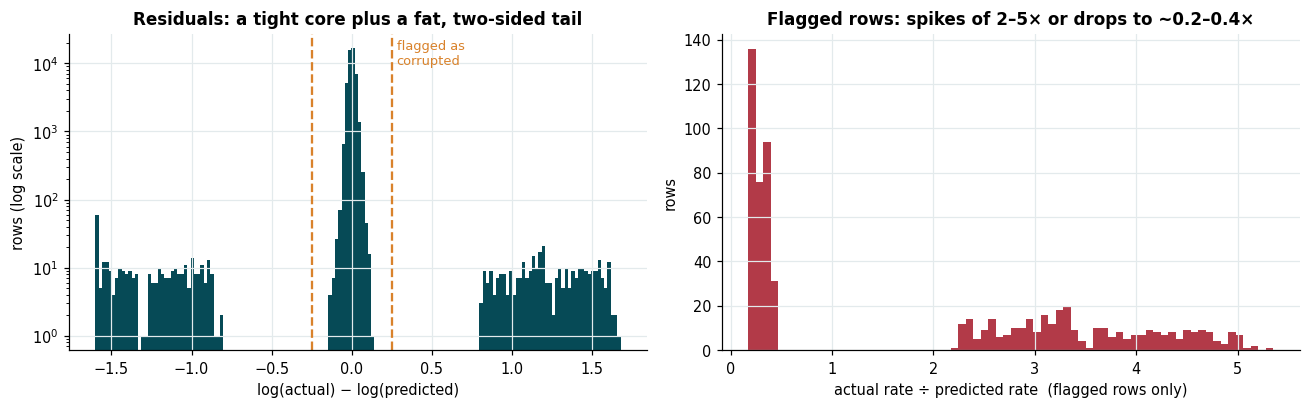

Gap between populations: largest |residual| among kept rows = 0.14, smallest among flagged rows = 0.80  (threshold 0.25) -> the threshold is not delicate
Flagged: 677 of 48,000 rows = 1.41%  (340 spikes, 337 drops)
Typical error on the other 98.6% of rows: median |log error| = 0.0135 (≈1.3%)
Spike size: median 3.3× the expected rate;  drop size: median 0.28× the expected rate


In [10]:
resid = np.log(train[TARGET].values) - final.predict_log(train)
flag = ~final.keep_mask
spike, drop = flag & (resid > 0), flag & (resid < 0)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
a = ax[0]
a.hist(np.clip(resid, -1.6, 1.8), bins=160, color=TEAL)
a.axvline(CLEAN_THRESHOLD, color=ORANGE, ls="--"); a.axvline(-CLEAN_THRESHOLD, color=ORANGE, ls="--")
a.set(yscale="log", xlabel="log(actual) − log(predicted)", ylabel="rows (log scale)",
      title="Residuals: a tight core plus a fat, two-sided tail")
a.text(CLEAN_THRESHOLD + .03, a.get_ylim()[1] * .35, f"flagged as\ncorrupted", color=ORANGE, fontsize=8.5)

b = ax[1]
factor = np.exp(resid[flag])
b.hist(np.clip(factor, 0, 6), bins=70, color=RED)
b.set(xlabel="actual rate ÷ predicted rate  (flagged rows only)", ylabel="rows", title="Flagged rows: spikes of 2–5× or drops to ~0.2–0.4×")
plt.tight_layout(); plt.show()

print(f"Gap between populations: largest |residual| among kept rows = {np.abs(resid[~flag]).max():.2f}, smallest among flagged rows = {np.abs(resid[flag]).min():.2f}  (threshold {CLEAN_THRESHOLD}) -> the threshold is not delicate")
print(f"Flagged: {flag.sum()} of {len(train):,} rows = {flag.mean():.2%}  ({spike.sum()} spikes, {drop.sum()} drops)")
print(f"Typical error on the other {100 * (1 - flag.mean()):.1f}% of rows: median |log error| = {np.median(np.abs(resid[~flag])):.4f} (≈{100 * np.median(np.abs(resid[~flag])):.1f}%)")
print(f"Spike size: median {np.median(np.exp(resid[spike])):.1f}× the expected rate;  drop size: median {np.median(np.exp(resid[drop])):.2f}× the expected rate")

**Are the flagged rows a pattern I should model, or plain corruption?** If they came from a real mechanism (say a specific equipment type or month), they'd concentrate there. They don't:

In [11]:
chk = train.assign(flagged=flag, dist_bucket=pd.qcut(train.distance, 4, labels=["shortest 25%", "25-50%", "50-75%", "longest 25%"]))
rates = pd.concat({
    "equipment": chk.groupby("equipment").flagged.mean(),
    "distance quartile": chk.groupby("dist_bucket", observed=True).flagged.mean(),
    "month": chk.groupby(chk.date.dt.strftime("%Y-%m")).flagged.mean(),
}) * 100
print("Share of rows flagged (%), by segment:")
print(rates.round(2).to_string())

Share of rows flagged (%), by segment:
equipment          Dry Van        1.350
                   Flatbed        1.450
                   Reefer         1.510
distance quartile  shortest 25%   1.500
                   25-50%         1.580
                   50-75%         1.340
                   longest 25%    1.230
month              2025-01        1.650
                   2025-02        1.310
                   2025-03        1.410
                   2025-04        1.370
                   2025-05        1.260
                   2025-06        1.320
                   2025-07        1.320
                   2025-08        1.430
                   2025-09        1.370
                   2025-10        1.650


The flagged share is ~1.4% almost everywhere, so these are **random label corruption, unrelated to any feature**. There is nothing to learn from them, and leaving them in would drag the model toward outliers. Decision: **drop them from training only; never from evaluation** (the final labels will contain them too, so I report both all-row and "core" metrics in §6).

### 5.4 What the linear part learned

The market effect is invisible in raw correlations (§3) but obvious once load shape is removed. Below, the *daily average* of what the GBM leaves unexplained tracks the fitted linear part closely: a weekly market wave riding on a slow upward drift.

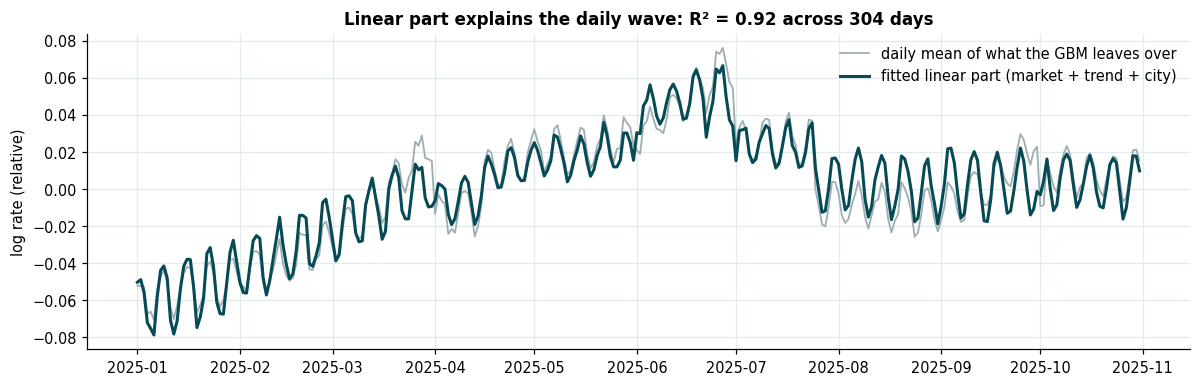

In [12]:
kept = train[final.keep_mask].copy()
kept["gbm_part"] = final.gbm.predict(final._gbm_features(kept))
kept["target_resid"] = np.log(kept[TARGET]) - kept["gbm_part"]
kept["fitted_resid"] = final.predict_log(kept) - kept["gbm_part"]
daily = kept.groupby("date")[["target_resid", "fitted_resid"]].mean()
r2 = np.corrcoef(daily.target_resid, daily.fitted_resid)[0, 1] ** 2

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(daily.index, daily.target_resid, color=GREY, lw=1.2, label="daily mean of what the GBM leaves over")
ax.plot(daily.index, daily.fitted_resid, color=TEAL, lw=2, label="fitted linear part (market + trend + city)")
ax.set(ylabel="log rate (relative)", title=f"Linear part explains the daily wave: R² = {r2:.2f} across {len(daily)} days")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

**City effects** are small but consistent, and mostly smooth in geography: the Northeast and Great Lakes run a few percent below average, Texas and Oklahoma a few percent above. That smoothness is exactly why a **kNN on coordinates** is a sensible way to price a city the model has never seen.

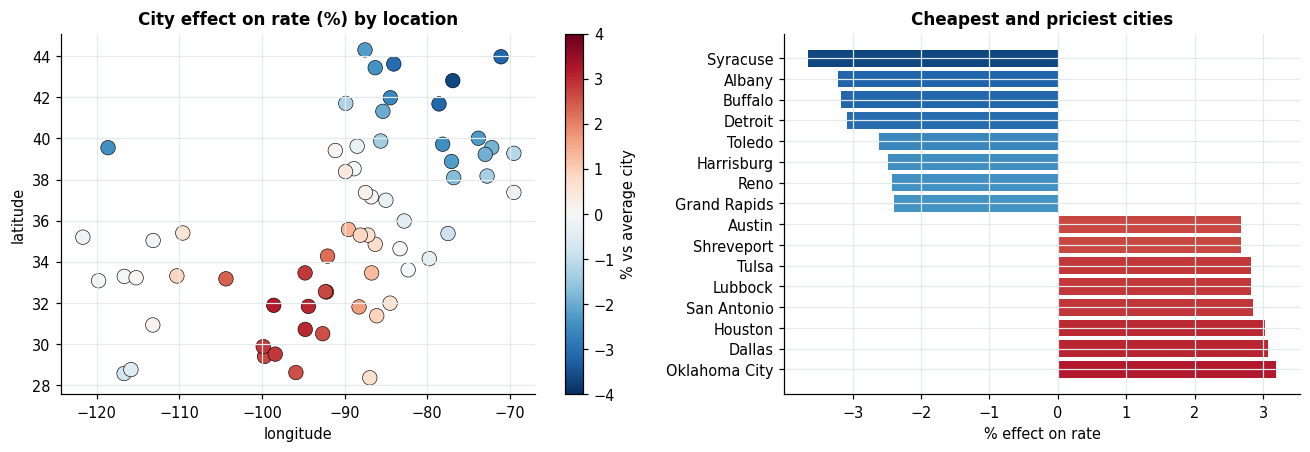

In [13]:
eff = final.city_effect * 100
pts = pd.DataFrame(final.coords, index=["lat", "lon"]).T.loc[eff.index]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.15, 1]})
sc = ax[0].scatter(pts.lon, pts.lat, c=eff, cmap="RdBu_r", vmin=-4, vmax=4, s=90, edgecolor="k", lw=.4)
ax[0].set(xlabel="longitude", ylabel="latitude", title="City effect on rate (%) by location")
plt.colorbar(sc, ax=ax[0], label="% vs average city")
extreme = pd.concat([eff.sort_values().head(8), eff.sort_values().tail(8)])
ax[1].barh(extreme.index, extreme.values, color=plt.cm.RdBu_r((extreme.values + 4) / 8))
ax[1].set(xlabel="% effect on rate", title="Cheapest and priciest cities"); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

---
## 6. Results

### 6.1 Forward-in-time cross-validation

All three models on the same five folds. **MAE / MAPE** are computed on *all* rows (including corrupted labels). **Core** metrics exclude rows whose label is implausible, so they show how well the model prices real loads.

In [14]:
cv = V.rolling_origin_cv(train, ctx, verbose=False)
METRICS = ["MAE", "MAPE", "MedAPE", "core_MAPE", "core_logMAE", "bias_pct"]
summary = cv.groupby("model")[METRICS].mean()
summary.columns = ["MAE ($)", "MAPE (%)", "Median APE (%)", "Core MAPE (%)", "Core log-MAE", "Median bias (%)"]
display(summary.style.format("{:.2f}").format("{:.4f}", subset=["Core log-MAE"])
        .highlight_min(color="#CFE8D5", subset=summary.columns[:5], axis=0))

base, plain, hyb = summary.iloc[0], summary.iloc[1], summary.iloc[2]
print(f"Hybrid vs plain LightGBM: MAE {100 * (1 - hyb['MAE ($)'] / plain['MAE ($)']):.0f}% lower, core MAPE {100 * (1 - hyb['Core MAPE (%)'] / plain['Core MAPE (%)']):.0f}% lower")
print(f"Hybrid vs per-mile baseline: MAE {100 * (1 - hyb['MAE ($)'] / base['MAE ($)']):.0f}% lower")

,MAE ($),MAPE (%),Median APE (%),Core MAPE (%),Core log-MAE,Median bias (%)
model,,,,,,
1. Median $/mile baseline,220.70,10.46,6.87,7.45,0.0766,-2.22
2. Plain LightGBM,119.53,5.03,2.28,2.81,0.0286,-1.80
3. Hybrid (final),104.59,4.51,1.92,2.22,0.0220,0.78


Hybrid vs plain LightGBM: MAE 12% lower, core MAPE 21% lower
Hybrid vs per-mile baseline: MAE 53% lower


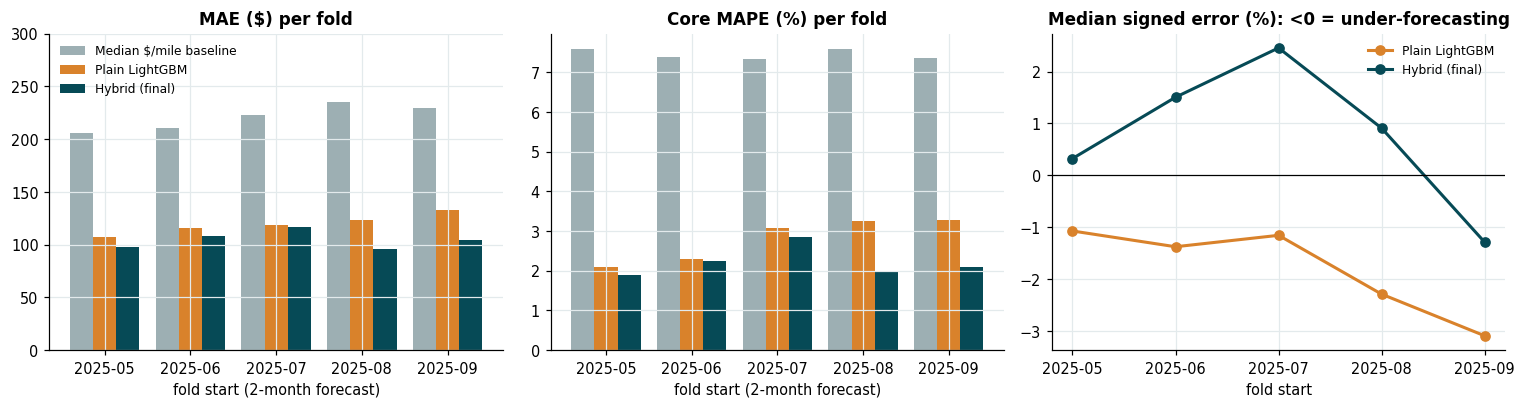

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
names = cv.model.unique()
pal = {names[0]: GREY, names[1]: ORANGE, names[2]: TEAL}
folds_ = cv.fold.unique()
x = np.arange(len(folds_))

for a, metric, title in ((ax[0], "MAE", "MAE ($) per fold"), (ax[1], "core_MAPE", "Core MAPE (%) per fold")):
    for i, m in enumerate(names):
        a.bar(x + (i - 1) * .27, cv[cv.model == m][metric].values, .27, color=pal[m], label=m[3:])
    a.set(xticks=x, xticklabels=folds_, title=title, xlabel="fold start (2-month forecast)")
ax[0].set_ylim(0, 300); ax[0].legend(frameon=False, fontsize=8, loc="upper left")

for m in names[1:]:
    ax[2].plot(folds_, cv[cv.model == m].bias_pct.values, marker="o", color=pal[m], label=m[3:], lw=2)
ax[2].axhline(0, color="k", lw=.8)
ax[2].set(title="Median signed error (%): <0 = under-forecasting", xlabel="fold start")
ax[2].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

**Reading the charts**

- The hybrid beats the plain LightGBM on **all five folds** (MAE and core MAPE), and the gap is widest in the August and September folds, where the trend has had the most time to build.
- The plain LightGBM **under-forecasts more and more** (median error drifts from about −1% to −3%), which is the signature of a tree that cannot continue the upward drift. The hybrid's bias stays within roughly ±2.5% and is −1.3% in the last fold.
- Both ML models are far ahead of the per-mile rule of thumb.

### 6.2 Why not a random split? (measured, not assumed)

Here is the *same plain LightGBM* scored two ways: with a shuffled 5-fold CV (the "obvious" way), and forward-in-time.

In [16]:
random_scores = V.random_split_cv(train)
forward_scores = cv[cv.model == names[1]][METRICS].mean()

cmp = pd.DataFrame({
    "Shuffled 5-fold CV (leaky)": [random_scores["MAE"], random_scores["MAPE"], random_scores["core_MAPE"]],
    "Forward-in-time CV (honest)": [forward_scores["MAE"], forward_scores["MAPE"], forward_scores["core_MAPE"]],
}, index=["MAE ($)", "MAPE (%)", "Core MAPE (%)"])
cmp["Random split looks better by"] = (1 - cmp.iloc[:, 0] / cmp.iloc[:, 1]).map("{:.0%}".format)
display(cmp.style.format({cmp.columns[0]: "{:.2f}", cmp.columns[1]: "{:.2f}"}))

,Shuffled 5-fold CV (leaky),Forward-in-time CV (honest),Random split looks better by
MAE ($),90.76,119.53,24%
MAPE (%),4.16,5.03,17%
Core MAPE (%),1.78,2.81,37%


A shuffled split makes the *same model* look **17–37% better** than it will be on genuinely future data, because it trains on days around every test row. Trusting it, I'd have reported a much better number than I'd deliver on Nov–Dec. This is why the forward folds are the only numbers I quote.

### 6.3 Unseen cities

`validation.csv` has 8 cities that never appear in training (12% of its rows). To test the kNN fallback, I hid 8 *training* cities, refit, and forecast Sep–Oct loads touching them.

In [17]:
unseen_res = V.unseen_city_test(train, ctx)
unseen_res.columns = ["MAE ($)", "MAPE (%)", "Median APE (%)", "Core MAPE (%)", "Core log-MAE", "Median bias (%)"]
display(unseen_res.style.format("{:.3f}"))

,MAE ($),MAPE (%),Median APE (%),Core MAPE (%),Core log-MAE,Median bias (%)
Cities seen in training,103.279,4.023,1.764,2.086,0.021,-1.261
8 cities unseen (kNN fallback),108.485,4.189,1.953,2.261,0.023,-1.500


Losing a city's history costs only ~0.2 points of core MAPE (2.09% → 2.26%). The city effects are geographically smooth, so borrowing from neighbours works, and keeping geography in these smooth terms (rather than letting trees split on raw coordinates) means an unseen city never lands in a region of the trees that was never trained.

### 6.4 Where does the remaining error come from?

Refit on Jan–Aug, forecast Sep–Oct, and split the error.

In [18]:
fit_df, test_df = V.split_by_date(train, "2025-09-01", "2025-11-01")
m_last = FreightModel(ctx).fit(fit_df, np.log(fit_df[TARGET].values))
pred = m_last.predict(test_df)
y_true = test_df[TARGET].values
abs_err = np.abs(pred - y_true)
core = np.abs(np.log(y_true) - np.log(pred)) < CLEAN_THRESHOLD

print(f"{(~core).mean():.1%} of test rows are corrupted labels, but they cause {abs_err[~core].sum() / abs_err.sum():.0%} of the total dollar error.")
print(f"MAE on all rows: ${abs_err.mean():,.0f}   MAE on the {core.mean():.1%} core rows: ${abs_err[core].mean():,.0f}\n")

seg = test_df.assign(ape=100 * abs_err / y_true, core=core)
seg = seg[seg.core]
by_dist = seg.groupby(pd.cut(seg.distance, [0, 150, 500, 1000, 2000, 4000]), observed=True).ape.agg(["count", "mean"])
by_dist.columns = ["core rows", "MAPE (%)"]
display(by_dist.style.format({"MAPE (%)": "{:.2f}"}).set_caption("Core MAPE by distance band (miles)"))

floor = test_df.distance.values == 70
if floor.any():
    print(f"\n70-mile-floor loads ({floor.sum()} in this fold): median signed error {100 * np.median(np.log(pred[floor] / y_true[floor])):+.1f}% (positive = over-predicted)")

1.5% of test rows are corrupted labels, but they cause 54% of the total dollar error.
MAE on all rows: $104   MAE on the 98.5% core rows: $48



,core rows,MAPE (%)
distance,,
"(0, 150]",184,4.74
"(150, 500]",1871,2.26
"(500, 1000]",2927,2.05
"(1000, 2000]",2884,1.98
"(2000, 4000]",1513,1.95



70-mile-floor loads (13 in this fold): median signed error +6.8% (positive = over-predicted)


**Takeaway:** the leftover error is dominated by the corrupted labels, which no model can predict. On genuine loads the hybrid prices within about 2% (MAPE) for every distance band above 150 miles; the biggest relative errors are on very short hauls (≈5% under 150 mi), where a small dollar error is a large percentage. Loads sitting at the 70-mile floor are over-predicted by about 7% in this fold (small sample), a known weakness.

---
## 7. Decision log

| # | Decision | Why | Evidence |
|---|---|---|---|
| 1 | **Forward-in-time rolling CV** (5 folds, 2-month horizon), never a random split | Validation is a Nov–Dec forecast; time drift makes shuffled CV optimistic | §6.2 |
| 2 | **Model log(rate)** on **log(distance)** | Rate scales ~proportionally with distance; errors are naturally relative | §3 |
| 3 | **Drop ~1.4% corrupted training labels**, evaluation untouched | Random, feature-independent spikes/drops; cannot be learned and would bias the fit | §5.3 |
| 4 | **`abs(weight)`**, missing weight left as NaN | Negative weights are sign flips; LightGBM handles NaN | §2 |
| 5 | **Price with `distance`; coordinates only locate cities** | Coordinates add no information beyond distance (corr ≈ 1.0) and aren't real-world accurate | §2 |
| 6 | **Daily market context from `market_index` medians** (features only, no labels) | ~98% of its variance is between days; fixes blanks; covers Nov–Dec | §3 |
| 7 | **Hybrid (GBM + linear)** instead of a plain GBM | Trees can't extrapolate the time trend past training | §6.1 |
| 8 | **City effects + coordinate kNN** for unseen cities | 12% of validation rows touch an unseen city; effects are geographically smooth | §5.4, §6.3 |
| 9 | Log-space L2 with cleaned labels, i.e. target the *typical* rate | Suits MAE/MAPE-style scoring on data with outlier labels | §6.1 |

---
## 8. Final predictions and December chart

The model (`final`, fitted in §5.3) already uses **all 48,000 labeled rows**. Below I write the two deliverables using the shared `submission.py` helpers, run some sanity checks, and run the provided `score.py`.

In [19]:
val_sub = validation_submission(final, val, template)
dec_sub = december_submission(final, december)

OUT_DIR.mkdir(exist_ok=True)
val_sub.to_csv(OUT_DIR / "validation_predictions.csv", index=False)
dec_sub.to_csv(OUT_DIR / "december_chart_predictions.csv", index=False)

print(f"validation_predictions.csv: {val_sub.shape[0]:,} rows, columns = {list(val_sub.columns)}")
print(f"  all positive: {(val_sub.predicted_rate > 0).all()} | ids match template: {(val_sub.load_id == template.load_id).all()} | duplicates: {val_sub.load_id.duplicated().sum()}")
val_sub.head()

validation_predictions.csv: 12,000 rows, columns = ['load_id', 'predicted_rate']
  all positive: True | ids match template: True | duplicates: 0


,load_id,predicted_rate
0,TE-000001,860.670
1,TE-000002,"5,112.010"
2,TE-000003,"5,268.050"
3,TE-000004,"4,029.490"
4,TE-000005,"1,883.210"


### 8.1 Sanity checks on the 12,000 predictions

The predictions should look like a *continuation* of the training data: similar rate levels, and no jump at the Oct → Nov boundary.

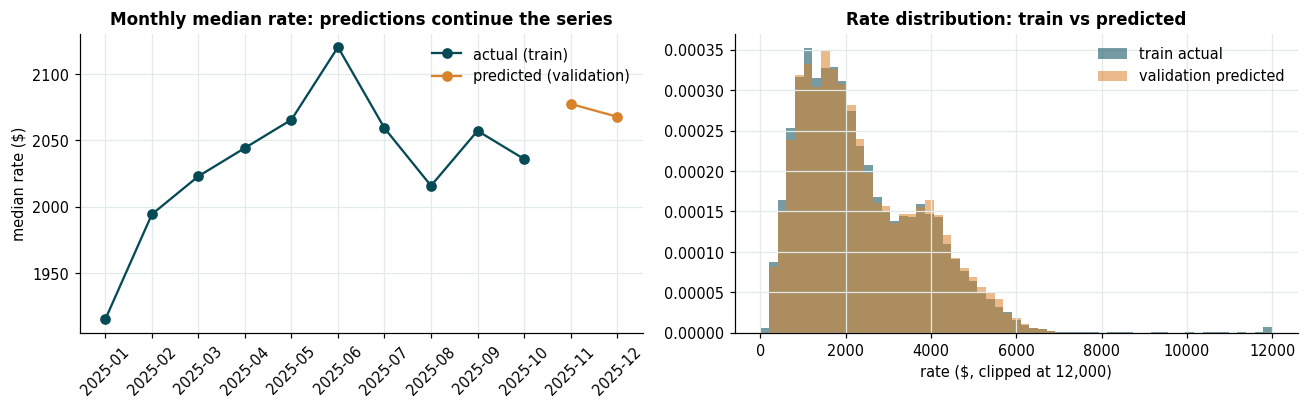

Predicted $/mile, loads touching an unseen city: 2.178  |  other loads: 2.179   (comparable, as expected)
Prediction range: $210 to $6,864   (train actual range: $57 to $25,533; the extremes there are corrupted labels)


In [20]:
scored = val.assign(pred=val_sub.set_index("load_id").loc[val.load_id, "predicted_rate"].values)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
monthly_actual = train.groupby(train.date.dt.to_period("M"))[TARGET].median()
monthly_pred = scored.groupby(scored.date.dt.to_period("M")).pred.median()
ax[0].plot(monthly_actual.index.astype(str), monthly_actual.values, marker="o", color=TEAL, label="actual (train)")
ax[0].plot(monthly_pred.index.astype(str), monthly_pred.values, marker="o", color=ORANGE, label="predicted (validation)")
ax[0].set(ylabel="median rate ($)", title="Monthly median rate: predictions continue the series")
ax[0].tick_params(axis="x", rotation=45); ax[0].legend(frameon=False)

bins = np.linspace(0, 12000, 60)
ax[1].hist(train[TARGET].clip(upper=12000), bins=bins, alpha=.55, color=TEAL, density=True, label="train actual")
ax[1].hist(scored.pred.clip(upper=12000), bins=bins, alpha=.55, color=ORANGE, density=True, label="validation predicted")
ax[1].set(xlabel="rate ($, clipped at 12,000)", title="Rate distribution: train vs predicted"); ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()

is_unseen = scored.pickup.isin(unseen) | scored.delivery.isin(unseen)
rpm = scored.pred / scored.distance
print(f"Predicted $/mile, loads touching an unseen city: {rpm[is_unseen].median():.3f}  |  other loads: {rpm[~is_unseen].median():.3f}   (comparable, as expected)")
print(f"Prediction range: ${scored.pred.min():,.0f} to ${scored.pred.max():,.0f}   (train actual range: ${train[TARGET].min():,.0f} to ${train[TARGET].max():,.0f}; the extremes there are corrupted labels)")

### 8.2 The fixed December chart (produced by the provided `score.py`)

One lane, **Lexington → Fort Wayne, 360 mi, Dry Van, 32,000 lb**; only the date changes. The chart file has no `market_index`, so each date uses that day's market level from `validation.csv` (feature columns only, never labels).

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: /home/claude/repo/outputs/scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


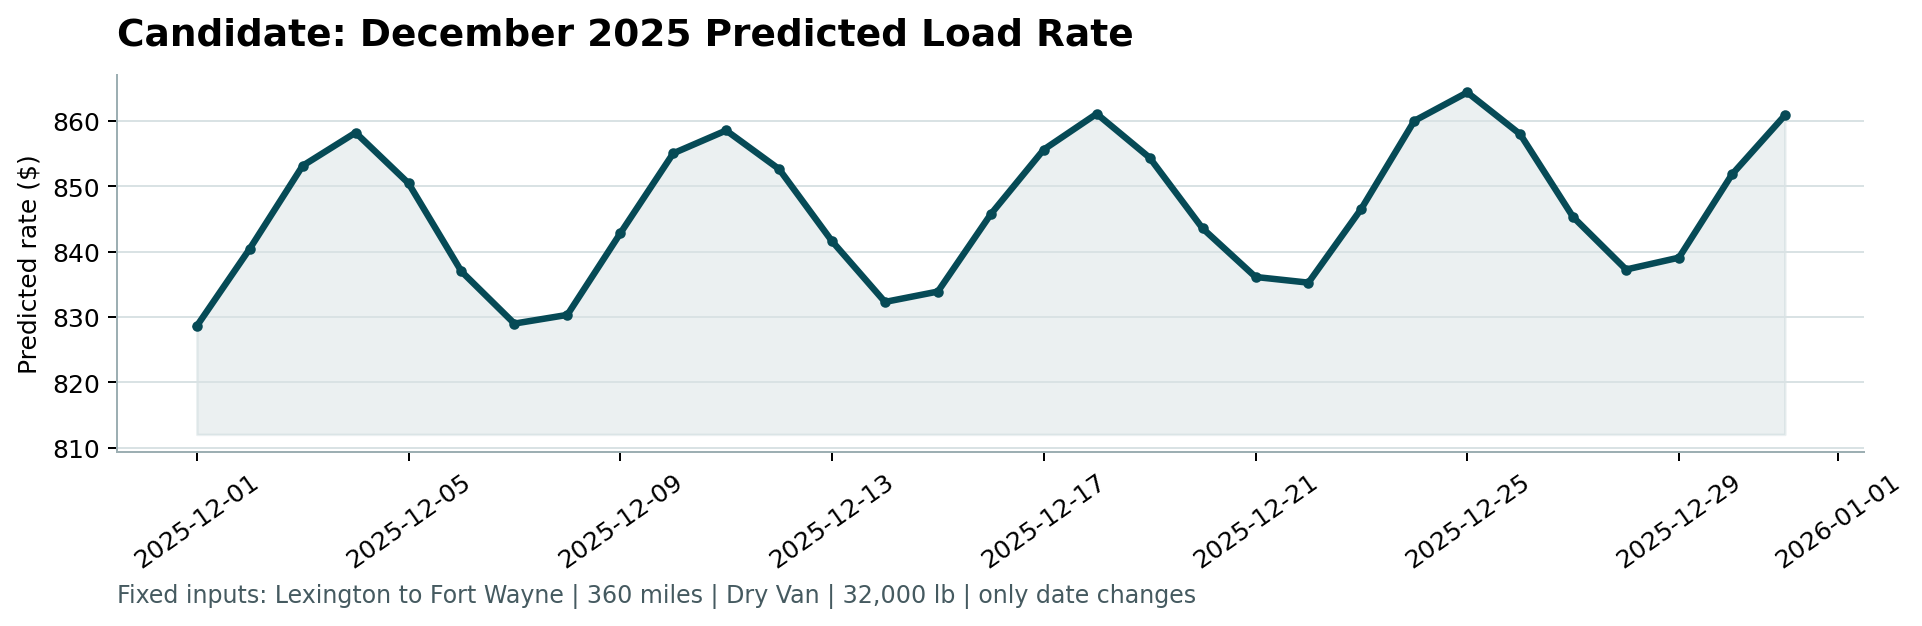

In [21]:
result = subprocess.run(
    [sys.executable, str(ROOT / "score.py"),
     "--predictions", str(OUT_DIR / "validation_predictions.csv"),
     "--december-predictions", str(OUT_DIR / "december_chart_predictions.csv"),
     "--output-dir", str(OUT_DIR / "scorer_results")],
    capture_output=True, text=True, cwd=ROOT)
print(result.stdout.strip() or result.stderr.strip())
Image(filename=str(OUT_DIR / "scorer_results" / "candidate_december.png"))

In [22]:
lane = train[(train.pickup == "Lexington") & (train.delivery == "Fort Wayne")]
hist = lane.groupby(lane.date.dt.strftime("%b")).posted_rate.agg(["count", "median"])
hist = hist.reindex(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct"])
print("Historical Lexington → Fort Wayne loads (all equipment), median actual rate by month:")
print(hist.rename(columns={"count": "loads", "median": "median rate ($)"}).T.round(0).to_string())
d = dec_sub.assign(date=pd.to_datetime(dec_sub.date))
print(f"\nDecember forecast: ${d.predicted_rate.min():,.0f} to ${d.predicted_rate.max():,.0f}, mean ${d.predicted_rate.mean():,.0f}; "
      f"highest on {d.loc[d.predicted_rate.idxmax(), 'date']:%a %b %d}, lowest on {d.loc[d.predicted_rate.idxmin(), 'date']:%a %b %d}")

Historical Lexington → Fort Wayne loads (all equipment), median actual rate by month:
date                Jan     Feb     Mar     Apr     May     Jun     Jul     Aug     Sep     Oct
loads             5.000   2.000   4.000   6.000   2.000   1.000   2.000   4.000   2.000   4.000
median rate ($) 788.000 831.000 809.000 849.000 916.000 824.000 879.000 923.000 869.000 853.000

December forecast: $829 to $864, mean $846; highest on Thu Dec 25, lowest on Mon Dec 01


The curve is a **weekly wave** (the market index peaks midweek) on a **slow upward drift** (the fitted ~0.7%/month trend), and it sits right in the range this lane's history suggests (monthly medians of \$790–\$920 from only 1–6 loads each, so a rough guide only). With everything else fixed, only the market level and the trend move it, which is what the chart is designed to expose.

> One caveat visible on the chart: Dec 25 is a Thursday, the weekly peak of the market index, so the model prices it as an ordinary Thursday. It has no knowledge of holidays (see §9).

---
## 9. Limitations and next steps

**Limitations (stated up front, not hidden):**

1. **Trend extrapolation.** The +0.7%/month drift is extended two months beyond the data. The forward folds support this (the plain GBM's growing under-forecast is the evidence), but the trend and the market's regime shifts are partly entangled in a single year of data, so the exact slope is an estimate. *December seasonality* (holidays, capacity) cannot be learned from Jan–Oct.
2. **Corrupted labels in the final scoring set.** ~1.4% of the held-out labels are probably corrupted too. They will dominate any squared-error metric, and no model can predict them. My training targets the *typical* rate, which suits MAE/MAPE.
3. **Lane-specific effects are not modelled.** Lanes have small individual premia, and 12% of validation rows are on lanes with an unseen city.
4. **Model selection used the same folds** as the reported CV, so the CV numbers are slightly optimistic.

**With more time:** a lane-level effect with shrinkage, an explicit holiday/seasonality signal if more history were available, prediction intervals (quantile GBM) so users see uncertainty on the December curve, and a monitoring job that watches the daily residual for the trend breaking.

---
## 10. Reproduce

```bash
pip install -r requirements.txt
python scripts/run_validation.py     # forward CV + unseen-city test -> outputs/cv_*.csv
python scripts/make_predictions.py   # final fit -> outputs/validation_predictions.csv, december_chart_predictions.csv
python score.py --predictions outputs/validation_predictions.csv \
                --december-predictions outputs/december_chart_predictions.csv \
                --output-dir outputs/scorer_results
python reports/build_report.py       # -> reports/report.pdf
```
Everything is seeded and deterministic; a rerun reproduces identical files.